# **Homework \#3**
### Author: Skyler Ruiter
### Date: November 7, 2025
### Course: Deep Learning Systems (ENGR-E 533)

---

# Setup:

Load the needed modules and setup the device for computation.

This homework adds the librosa and soundfile libraries

In [2]:
import torch
from torch.utils.data import DataLoader
import torchvision
import numpy as np
import time
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from IPython.display import Audio, display

print(torch.cuda.is_available())
device=torch.device('cuda')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(device)

True
cuda


In [3]:
mnist_train = torchvision.datasets.MNIST('mnist',
                                         train=True,
                                         download=True,
                                         transform=torchvision.transforms.Compose([
                                             torchvision.transforms.ToTensor(),
                                             torchvision.transforms.Normalize((0.1307,), (0.3081,))
                                         ]))
mnist_test = torchvision.datasets.MNIST('mnist',
                                        train=False,
                                        download=True,
                                        transform=torchvision.transforms.Compose([
                                            torchvision.transforms.ToTensor(),
                                            torchvision.transforms.Normalize((0.1307,), (0.3081,))
                                        ]))

X_train, y_train = mnist_train.data, mnist_train.targets
X_test, y_test = mnist_test.data, mnist_test.targets

X_train = X_train.float()
X_test = X_test.float()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = (X_train - 0.1307) / 0.3081
X_test = (X_test - 0.1307) / 0.3081

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

train_dataloader = DataLoader(mnist_train, batch_size=128, num_workers=4, pin_memory=True, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=128, num_workers=4, pin_memory=True, shuffle=True)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

100.0%
100.0%
100.0%
100.0%


Training data shape: torch.Size([60000, 28, 28]), torch.Size([60000])
Test data shape: torch.Size([10000, 28, 28]), torch.Size([10000])


# Problem 1: Network Compression Using SVD

Methods to train and evaluate a network on direct data

In [4]:
def train_direct(X, y, model, loss_fn, optimizer):
  model.train()
  
  pred = model(X)
  loss = loss_fn(pred, y)
  
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

def test_direct(X, y, model, loss_fn):
  model.eval()
  correct = 0
  with torch.no_grad():
    pred = model(X)
    correct = (pred.argmax(1) == y).type(torch.float).sum().item()
  return correct / len(y)

Method to plot the test accuracy over epochs

In [7]:
def plot_test_accuracy(test_accuracies):
    plt.plot(test_accuracies)
    plt.xlabel('Epoch')
    plt.ylabel('Test Accuracy')
    plt.title('Test Accuracy over Epochs')
    plt.grid()
    plt.show()

Couldn't use the same model as my first homework due to not having high enough baseline accuracy. 

I used some batch normalization layers and dropout to improve accuracy above 98%.

I also initialized weights using He initialization.

In [11]:
class ShallowNN(torch.nn.Module):
    def __init__(self):
        super(ShallowNN, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(28 * 28, 1024),
            torch.nn.BatchNorm1d(1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(1024, 1024),
            torch.nn.BatchNorm1d(1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(1024, 1024),
            torch.nn.BatchNorm1d(1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(1024, 1024),
            torch.nn.BatchNorm1d(1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(1024, 1024),
            torch.nn.BatchNorm1d(1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(1024, 10)
        )
        # initialize weights
        for m in self.linear:
            if isinstance(m, torch.nn.Linear):
                torch.nn.init.kaiming_normal_(m.weight)
                torch.nn.init.zeros_(m.bias)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)
        return x

I used cross-entropy loss and the adam optimizer with a learning rate of 0.003 for training and trained for 200 epochs.

The model converged to a training accuracy of 98% after around 50 epochs.

In [12]:
baseline_model = ShallowNN().to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=3e-3)

num_epochs = 200
test_accuracies = []

for epoch in range(num_epochs):
    train_direct(X_train, y_train, baseline_model, loss_fn, optimizer)
    acc = test_direct(X_test, y_test, baseline_model, loss_fn)
    test_accuracies.append(acc)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Test Accuracy: {acc:.4f}")

Epoch 10/200, Test Accuracy: 0.9002
Epoch 20/200, Test Accuracy: 0.9437
Epoch 30/200, Test Accuracy: 0.9666
Epoch 40/200, Test Accuracy: 0.9748
Epoch 50/200, Test Accuracy: 0.9783
Epoch 60/200, Test Accuracy: 0.9804
Epoch 70/200, Test Accuracy: 0.9811
Epoch 80/200, Test Accuracy: 0.9830
Epoch 90/200, Test Accuracy: 0.9830
Epoch 100/200, Test Accuracy: 0.9839
Epoch 110/200, Test Accuracy: 0.9837
Epoch 120/200, Test Accuracy: 0.9843
Epoch 130/200, Test Accuracy: 0.9846
Epoch 140/200, Test Accuracy: 0.9838
Epoch 150/200, Test Accuracy: 0.9844
Epoch 160/200, Test Accuracy: 0.9844
Epoch 170/200, Test Accuracy: 0.9845
Epoch 180/200, Test Accuracy: 0.9847
Epoch 190/200, Test Accuracy: 0.9851
Epoch 200/200, Test Accuracy: 0.9843


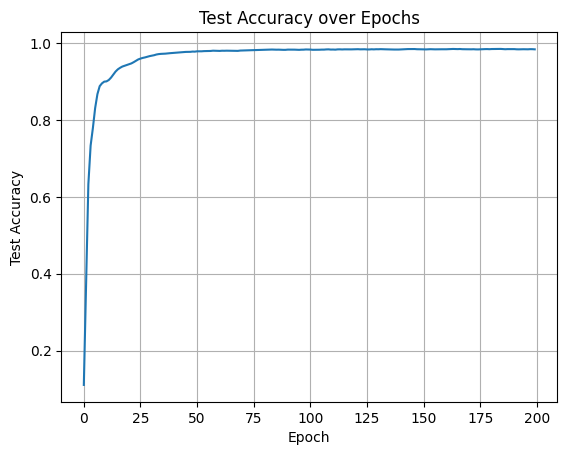

In [13]:
plot_test_accuracy(test_accuracies)

Test accuracy is getting a little above that 98% baseline threshold in my testing. Usually around 98.4% after 200 epochs.

Run the SVD once for each layer and then just vary the number of singular values to keep.

In [17]:
singular_value_thresholds = [10, 20, 50, 100, 200, -1]
svd_weights = []
for layer in baseline_model.linear:
    if isinstance(layer, torch.nn.Linear):
        W = layer.weight.data.cpu().numpy()
        U, S, Vt = np.linalg.svd(W, full_matrices=False)
        svd_weights.append((U, S, Vt))

# print dims
for i, (U, S, Vt) in enumerate(svd_weights):
    print(f"Layer {i}: U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")

Layer 0: U shape: (1024, 784), S shape: (784,), Vt shape: (784, 784)
Layer 1: U shape: (1024, 1024), S shape: (1024,), Vt shape: (1024, 1024)
Layer 2: U shape: (1024, 1024), S shape: (1024,), Vt shape: (1024, 1024)
Layer 3: U shape: (1024, 1024), S shape: (1024,), Vt shape: (1024, 1024)
Layer 4: U shape: (1024, 1024), S shape: (1024,), Vt shape: (1024, 1024)
Layer 5: U shape: (10, 10), S shape: (10,), Vt shape: (10, 1024)


I created a model that can take in the SVD weight matrices and a rank threshold so I could reuse the class for different ranks.

I initially messed up by forgetting to handle the bias terms.

In [52]:
class SVDCompressedNN(torch.nn.Module):
    def __init__(self, svd_weights, rank_threshold, baseline_model):
        super(SVDCompressedNN, self).__init__()
        self.flatten = torch.nn.Flatten()
        layers = []
        baseline_linear_layers = [m for m in baseline_model.linear if isinstance(m, torch.nn.Linear)]
        baseline_bn_layers = [m for m in baseline_model.linear if isinstance(m, torch.nn.BatchNorm1d)]
        for i, (U, S, Vt) in enumerate(svd_weights):
            if rank_threshold == -1:
                rank = len(S)
            else:
                rank = min(rank_threshold, len(S))
            U_k = U[:, :rank]
            S_k = S[:rank]
            Vt_k = Vt[:rank, :]
            W_compressed = U_k @ np.diag(S_k) @ Vt_k
            out_features, in_features = W_compressed.shape
            linear = torch.nn.Linear(in_features, out_features)
            linear.weight.data = torch.tensor(W_compressed, dtype=torch.float32)
            linear.bias.data = baseline_linear_layers[i].bias.data.cpu().clone()
            layers.append(linear)
            if i < len(svd_weights) - 1:
                bn = torch.nn.BatchNorm1d(out_features)
                bn.load_state_dict(baseline_bn_layers[i].state_dict())
                layers.append(bn)
                layers.append(torch.nn.ReLU())
                layers.append(torch.nn.Dropout(0.3))
        self.linear = torch.nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)
        return x

Generate the compressed models and evaluate their accuracies.

In [53]:
compressed_models = {}
for threshold in singular_value_thresholds:
    model = SVDCompressedNN(svd_weights, threshold, baseline_model).to(device)
    compressed_models[threshold] = model
    print(f"Created compressed model with rank threshold: {threshold}")

Created compressed model with rank threshold: 10
Created compressed model with rank threshold: 20
Created compressed model with rank threshold: 50
Created compressed model with rank threshold: 100
Created compressed model with rank threshold: 200
Created compressed model with rank threshold: -1


In [54]:
results = {}
for threshold, model in compressed_models.items():
    acc = test_direct(X_test, y_test, model, loss_fn)
    results[threshold] = acc
    print(f"Rank threshold {threshold}: Test Accuracy = {acc:.4f}")

Rank threshold 10: Test Accuracy = 0.7254
Rank threshold 20: Test Accuracy = 0.9127
Rank threshold 50: Test Accuracy = 0.9653
Rank threshold 100: Test Accuracy = 0.9747
Rank threshold 200: Test Accuracy = 0.9797
Rank threshold -1: Test Accuracy = 0.9843


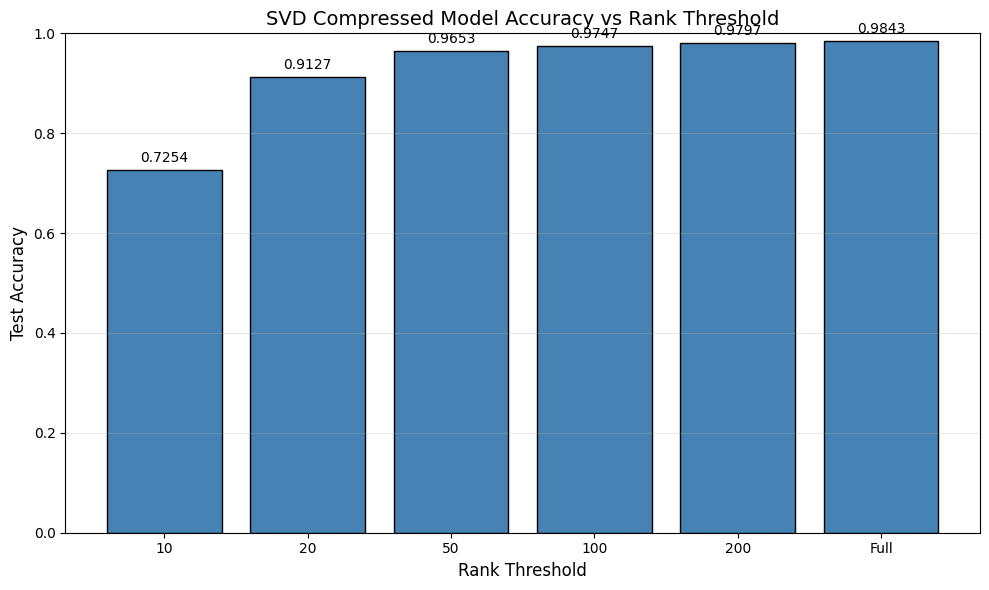

In [55]:
plt.figure(figsize=(10, 6))
thresholds = list(results.keys())
accuracies = list(results.values())
threshold_labels = [str(t) if t != -1 else "Full" for t in thresholds]
plt.bar(threshold_labels, accuracies, color='steelblue', edgecolor='black')
plt.xlabel('Rank Threshold', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('SVD Compressed Model Accuracy vs Rank Threshold', fontsize=14)
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
for i, (label, acc) in enumerate(zip(threshold_labels, accuracies)):
    plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

The accuracy is surprisingly resilient to SVD. Using even 100 ranks results in only a ~1% drop in accuracy. 10 ranks drops accuracy to 72 which is significant but the 20 rank model still gets above 90% accuracy, making it a good model to finetune further in the next questions.

In [56]:
def count_svd_parameters(svd_weights, rank_threshold):
    total_params = 0
    for i, (U, S, Vt) in enumerate(svd_weights):
        if rank_threshold == -1:
            continue
        else:
            rank = min(rank_threshold, len(S))
        out_features = U.shape[0]
        in_features = Vt.shape[1]
        layer_params = (out_features * rank) + rank + (rank * in_features) + out_features
        total_params += layer_params
        if i < len(svd_weights) - 1:
            total_params += 2 * out_features
    return total_params

baseline_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"Baseline Model Parameters: {baseline_params:,}")
print(f"\nSVD Compressed Model Parameters (Factorized Form):")
print("-" * 75)

compression_stats = {}
for threshold in singular_value_thresholds:
    if threshold == -1: continue
    svd_params = count_svd_parameters(svd_weights, threshold)
    compression_ratio = baseline_params / svd_params
    param_reduction = (1 - svd_params / baseline_params) * 100
    
    compression_stats[threshold] = {
        'params': svd_params,
        'compression_ratio': compression_ratio,
        'reduction_pct': param_reduction,
        'accuracy': results[threshold]
    }
    
    threshold_label = "Full" if threshold == -1 else str(threshold)
    print(f"Rank {threshold_label:>4}: {svd_params:>10,} params | "
          f"Compression: {compression_ratio:>5.2f}x | "
          f"Reduction: {param_reduction:>5.2f}% | "
          f"Accuracy: {results[threshold]:.4f}")

Baseline Model Parameters: 5,022,730

SVD Compressed Model Parameters (Factorized Form):
---------------------------------------------------------------------------
Rank   10:    125,770 params | Compression: 39.94x | Reduction: 97.50% | Accuracy: 0.7254
Rank   20:    225,820 params | Compression: 22.24x | Reduction: 95.50% | Accuracy: 0.9127
Rank   50:    525,970 params | Compression:  9.55x | Reduction: 89.53% | Accuracy: 0.9653
Rank  100:  1,026,220 params | Compression:  4.89x | Reduction: 79.57% | Accuracy: 0.9747
Rank  200:  2,026,720 params | Compression:  2.48x | Reduction: 59.65% | Accuracy: 0.9797


The number of parameters and accuracies for each rank. Even 200 rank is less than half the original model's parameters.

# Problem 2: Network Compression Using SVD

Define a class to learn U and V instead of full W. Initializes U and V with the SVD results from problem 1.

In [ ]:
class FactorizedSVDNet(torch.nn.Module):
    def __init__(self, svd_weights, rank=20):
        super(FactorizedSVDNet, self).__init__()
        self.flatten = torch.nn.Flatten()
        
        # store U and V as parameters instead of W
        self.U_layers = torch.nn.ParameterList()
        self.V_layers = torch.nn.ParameterList()
        self.bias_layers = torch.nn.ParameterList()
        
        # batch norm and activation layers
        self.batch_norms = torch.nn.ModuleList()
        self.dropouts = torch.nn.ModuleList()
        
        for i, (U, S, Vt) in enumerate(svd_weights):
            # init U w/ first 20 singular vectors
            U_init = U[:, :rank]
            
            # init V_t
            S_diag = np.diag(S[:rank])
            Vt_init = S_diag @ Vt[:rank, :]
            
            # create parameters
            U_param = torch.nn.Parameter(torch.tensor(U_init, dtype=torch.float32))
            V_param = torch.nn.Parameter(torch.tensor(Vt_init, dtype=torch.float32))
            bias_param = torch.nn.Parameter(torch.zeros(U_init.shape[0], dtype=torch.float32))
            self.U_layers.append(U_param)
            self.V_layers.append(V_param)
            self.bias_layers.append(bias_param)
            
            # add batch norm, relu, dropout except for last layer
            if i < len(svd_weights) - 1:
                self.batch_norms.append(torch.nn.BatchNorm1d(U_init.shape[0]))
                self.dropouts.append(torch.nn.Dropout(0.3))
            else:
                self.batch_norms.append(None)
                self.dropouts.append(None)
    def forward(self, x):
        x = self.flatten(x)
        for i in range(len(self.U_layers)):
            W = self.U_layers[i] @ self.V_layers[i]
            x = torch.nn.functional.linear(x, W, self.bias_layers[i])
            if i < len(self.U_layers) - 1:
                x = self.batch_norms[i](x)
                x = torch.nn.functional.relu(x)
                x = self.dropouts[i](x)
        return x

Creates the model and trains it with 200 epochs and cross-entropy loss w/ adam optimizer with a lower learning rate (due to p1 initialized weights)

In [33]:
factorized_model = FactorizedSVDNet(svd_weights, rank=20).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(factorized_model.parameters(), lr=5e-4)

num_epochs = 200
factorized_test_accuracies = []

for epoch in range(num_epochs):
    train_direct(X_train, y_train, factorized_model, loss_fn, optimizer)
    acc = test_direct(X_test, y_test, factorized_model, loss_fn)
    factorized_test_accuracies.append(acc)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Test Accuracy: {acc:.4f}")

Epoch 10/200, Test Accuracy: 0.9284
Epoch 20/200, Test Accuracy: 0.9634
Epoch 30/200, Test Accuracy: 0.9708
Epoch 40/200, Test Accuracy: 0.9724
Epoch 50/200, Test Accuracy: 0.9737
Epoch 60/200, Test Accuracy: 0.9751
Epoch 70/200, Test Accuracy: 0.9757
Epoch 80/200, Test Accuracy: 0.9758
Epoch 90/200, Test Accuracy: 0.9764
Epoch 100/200, Test Accuracy: 0.9771
Epoch 110/200, Test Accuracy: 0.9772
Epoch 120/200, Test Accuracy: 0.9782
Epoch 130/200, Test Accuracy: 0.9787
Epoch 140/200, Test Accuracy: 0.9787
Epoch 150/200, Test Accuracy: 0.9785
Epoch 160/200, Test Accuracy: 0.9783
Epoch 170/200, Test Accuracy: 0.9790
Epoch 180/200, Test Accuracy: 0.9793
Epoch 190/200, Test Accuracy: 0.9799
Epoch 200/200, Test Accuracy: 0.9797


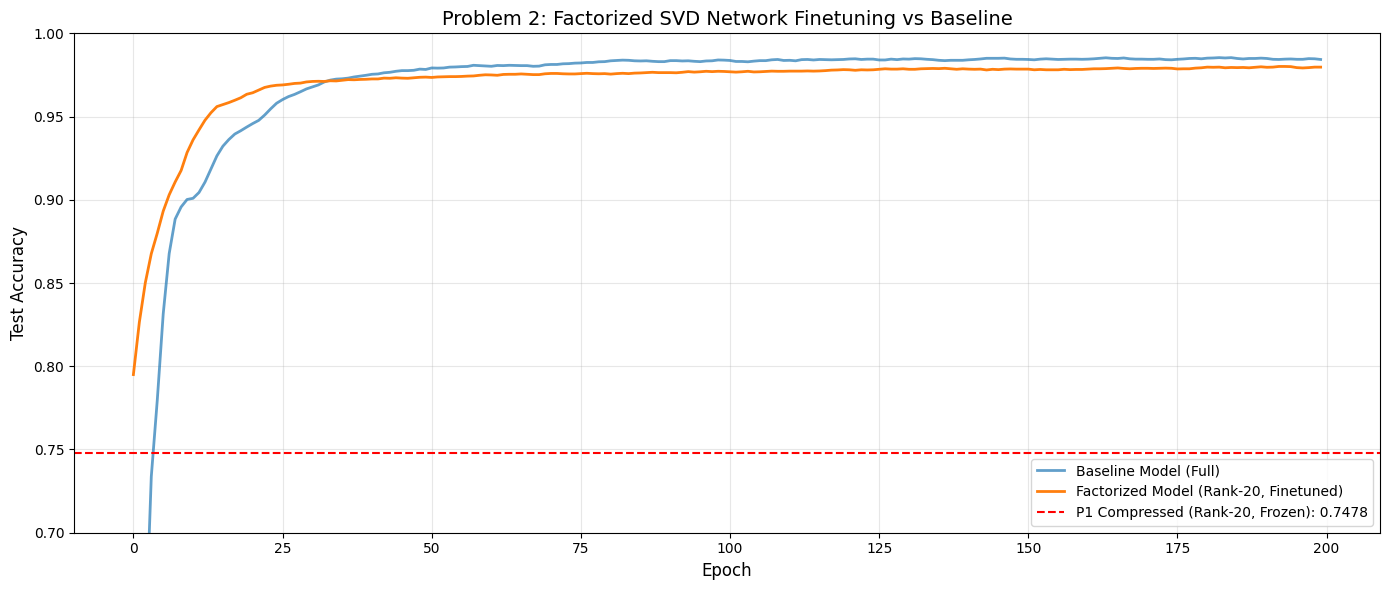

In [35]:
plt.figure(figsize=(14, 6))
plt.plot(test_accuracies, label='Baseline Model (Full)', linewidth=2, alpha=0.7)
plt.plot(factorized_test_accuracies, label='Factorized Model (Rank-20, Finetuned)', linewidth=2)
plt.axhline(y=results[20], color='r', linestyle='--', label=f'P1 Compressed (Rank-20, Frozen): {results[20]:.4f}', linewidth=1.5)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Problem 2: Factorized SVD Network Finetuning vs Baseline', fontsize=14)
plt.ylim([0.70, 1.00])
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The accuracies for the factorized model after fine-tuning comes quite close to the original accuracy despite having far fewer parameters. In my testing it falls around a half point behind the original test accuracy. It also reaches this accuracy fairly quickly.

# Problem 3: Network Compression Using SVD

Defining a network that runs SVD at each epoch is quite a bit more complex.

I created a new layer class that does the SVD weight approximation during the forward pass.

Then I define a model that uses these SVD enabled layers to create the same architecture as before.

In [36]:
class SVDAwareLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, rank=20):
        super(SVDAwareLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
    def forward(self, x):
        U, S, Vt = torch.linalg.svd(self.weight, full_matrices=False)
        U_k = U[:, :self.rank]
        S_k = S[:self.rank]
        Vt_k = Vt[:self.rank, :]
        W_approx = U_k @ torch.diag(S_k) @ Vt_k
        return torch.nn.functional.linear(x, W_approx, self.bias)

class SVDAwareNetwork(torch.nn.Module):
    def __init__(self, baseline_model, rank=20):
      super(SVDAwareNetwork, self).__init__()
      self.flatten = torch.nn.Flatten()
      layers = [m for m in baseline_model.linear if isinstance(m, torch.nn.Linear)]
      self.svd_layers = torch.nn.ModuleList()
      self.batch_norms = torch.nn.ModuleList()
      self.dropouts = torch.nn.ModuleList()
      for i, layer in enumerate(layers):
          svd_layer = SVDAwareLinear(layer.in_features, layer.out_features, rank=rank)
          svd_layer.weight.data.copy_(layer.weight.data)
          svd_layer.bias.data.copy_(layer.bias.data)
          self.svd_layers.append(svd_layer)
          if i < len(layers) - 1:
              self.batch_norms.append(torch.nn.BatchNorm1d(layer.out_features))
              self.dropouts.append(torch.nn.Dropout(0.3))
          else:
              self.batch_norms.append(None)
              self.dropouts.append(None)
    def forward(self, x):
        x = self.flatten(x)
        for i, svd_layer in enumerate(self.svd_layers):
            x = svd_layer(x)
            if i < len(self.svd_layers) - 1:
                x = self.batch_norms[i](x)
                x = torch.nn.functional.relu(x)
                x = self.dropouts[i](x)
        return x

In [37]:
svd_aware_model = SVDAwareNetwork(baseline_model, rank=20).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(svd_aware_model.parameters(), lr=1e-3)

num_epochs = 200
svd_aware_test_accuracies = []

for epoch in range(num_epochs):
    train_direct(X_train, y_train, svd_aware_model, loss_fn, optimizer)
    acc = test_direct(X_test, y_test, svd_aware_model, loss_fn)
    svd_aware_test_accuracies.append(acc)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Test Accuracy: {acc:.4f}")

Epoch 10/200, Test Accuracy: 0.9377
Epoch 20/200, Test Accuracy: 0.9721
Epoch 30/200, Test Accuracy: 0.9776
Epoch 40/200, Test Accuracy: 0.9793
Epoch 50/200, Test Accuracy: 0.9798
Epoch 60/200, Test Accuracy: 0.9807
Epoch 70/200, Test Accuracy: 0.9800
Epoch 80/200, Test Accuracy: 0.9805
Epoch 90/200, Test Accuracy: 0.9815
Epoch 100/200, Test Accuracy: 0.9808
Epoch 110/200, Test Accuracy: 0.9813
Epoch 120/200, Test Accuracy: 0.9811
Epoch 130/200, Test Accuracy: 0.9817
Epoch 140/200, Test Accuracy: 0.9817
Epoch 150/200, Test Accuracy: 0.9805
Epoch 160/200, Test Accuracy: 0.9821
Epoch 170/200, Test Accuracy: 0.9812
Epoch 180/200, Test Accuracy: 0.9817
Epoch 190/200, Test Accuracy: 0.9813
Epoch 200/200, Test Accuracy: 0.9815


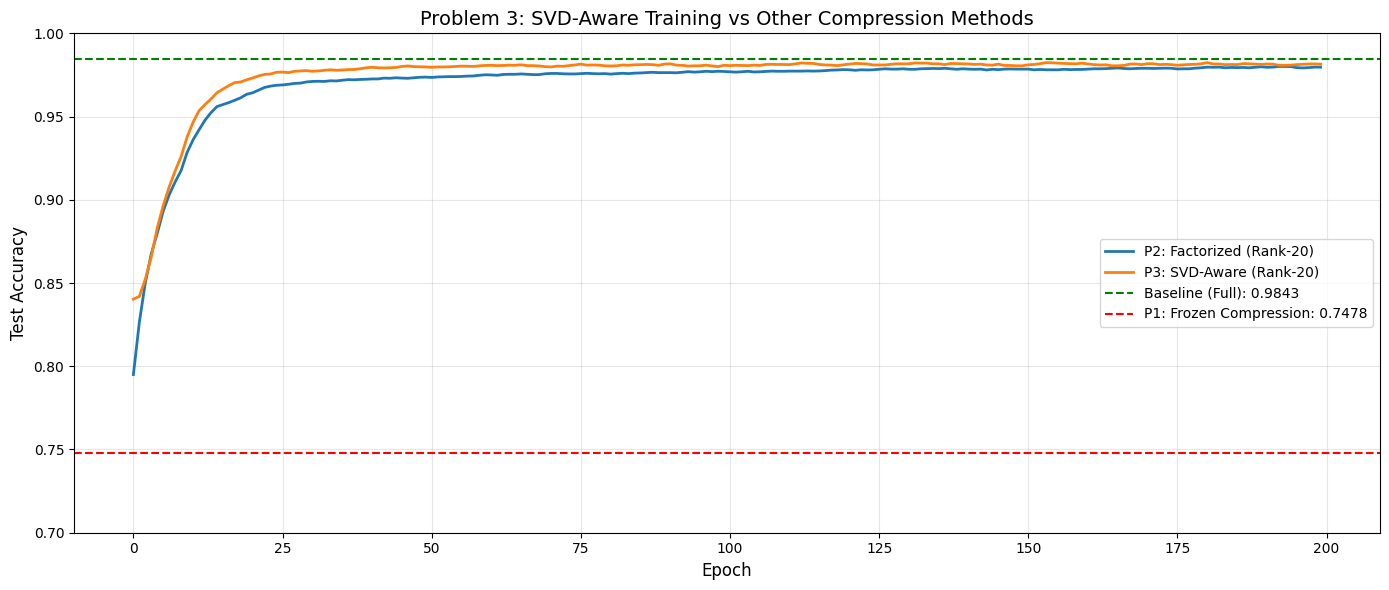

In [38]:
plt.figure(figsize=(14, 6))
plt.plot(factorized_test_accuracies, label='P2: Factorized (Rank-20)', linewidth=2)
plt.plot(svd_aware_test_accuracies, label='P3: SVD-Aware (Rank-20)', linewidth=2)
plt.axhline(y=test_accuracies[-1], color='g', linestyle='--', 
            label=f'Baseline (Full): {test_accuracies[-1]:.4f}', linewidth=1.5)
plt.axhline(y=results[20], color='r', linestyle='--', 
            label=f'P1: Frozen Compression: {results[20]:.4f}', linewidth=1.5)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Problem 3: SVD-Aware Training vs Other Compression Methods', fontsize=14)
plt.ylim([0.70, 1.00])
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The factorized model did a great job of catching up to the original accuracy. But the SVD-aware model did an even better job. Where the factorized model was around a half point behind the SVD-aware model was only around a quarter point behind the original accuracy. The gains are minor but still meaningful at these high accuracies.

Since the SVD-aware model is trained on a full set of weight matrices I need to build a compressed version for the parameter comparison. 

Below are the final accuracies and parameter counts for each model.

In [47]:
class CompressedSVDAwareNet(torch.nn.Module):
    def __init__(self, svd_aware_model, rank=20):
        super(CompressedSVDAwareNet, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.rank = rank
        self.U_layers = torch.nn.ParameterList()
        self.S_layers = torch.nn.ParameterList()
        self.Vt_layers = torch.nn.ParameterList()
        self.bias_layers = torch.nn.ParameterList()
        self.batch_norms = torch.nn.ModuleList()
        self.dropouts = torch.nn.ModuleList()
        with torch.no_grad():
            for i, svd_layer in enumerate(svd_aware_model.svd_layers):
                U, S, Vt = torch.linalg.svd(svd_layer.weight.data, full_matrices=False)
                U_k = U[:, :rank].clone()
                S_k = S[:rank].clone()
                Vt_k = Vt[:rank, :].clone()
                self.U_layers.append(torch.nn.Parameter(U_k, requires_grad=False))
                self.S_layers.append(torch.nn.Parameter(S_k, requires_grad=False))
                self.Vt_layers.append(torch.nn.Parameter(Vt_k, requires_grad=False))
                self.bias_layers.append(torch.nn.Parameter(svd_layer.bias.data.clone(), requires_grad=False))
                if i < len(svd_aware_model.svd_layers) - 1:
                    bn = torch.nn.BatchNorm1d(svd_layer.out_features)
                    bn.load_state_dict(svd_aware_model.batch_norms[i].state_dict())
                    self.batch_norms.append(bn)
                    self.dropouts.append(torch.nn.Dropout(0.3))
                else:
                    self.batch_norms.append(None)
                    self.dropouts.append(None)
    
    def forward(self, x):
        x = self.flatten(x)
        for i in range(len(self.U_layers)):
            W_approx = self.U_layers[i] @ torch.diag(self.S_layers[i]) @ self.Vt_layers[i]
            x = torch.nn.functional.linear(x, W_approx, self.bias_layers[i])
            if i < len(self.U_layers) - 1:
                x = self.batch_norms[i](x)
                x = torch.nn.functional.relu(x)
                x = self.dropouts[i](x)
        return x

compressed_svd_aware_model = CompressedSVDAwareNet(svd_aware_model, rank=20).to(device)

test_acc = test_direct(X_test, y_test, compressed_svd_aware_model, loss_fn)
print(f"\nCompressed SVD-Aware Model (Frozen, Rank-20)")
print(f"Test Accuracy: {test_acc:.4f}")

def count_compressed_params(model, rank):
    total_params = 0
    for i in range(len(model.U_layers)):
        out_features = model.U_layers[i].shape[0]
        in_features = model.Vt_layers[i].shape[1]
        layer_params = (out_features * rank) + rank + (rank * in_features) + out_features
        total_params += layer_params
        if i < len(model.U_layers) - 1:
            total_params += 2 * out_features  # weight and bias for BN
    
    return total_params

compressed_params = count_compressed_params(compressed_svd_aware_model, 20)
baseline_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)

print(f"\nParameter Comparison:")
print(f"Baseline Model: {baseline_params:,} parameters")
print(f"Compressed SVD-Aware Model: {compressed_params:,} parameters")
print(f"Compression Ratio: {baseline_params / compressed_params:.2f}x")
print(f"Parameter Reduction: {(1 - compressed_params / baseline_params) * 100:.2f}%")


Compressed SVD-Aware Model (Frozen, Rank-20)
Test Accuracy: 0.9815

Parameter Comparison:
Baseline Model: 5,022,730 parameters
Compressed SVD-Aware Model: 236,170 parameters
Compression Ratio: 21.27x
Parameter Reduction: 95.30%


# Problem 4: Speaker Verification

Load the data and create train/test splits

In [70]:
import pickle

with open('trs.pkl', 'rb') as f:
    train_data = pickle.load(f) # 500 x 16,180 (50 speakers, 10 utterances each)
    
with open('tes.pkl', 'rb') as f:
    test_data = pickle.load(f)  # 200 x 16,180 (20 speakers, 10 utterances each)

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

num_train_speakers = 50
utterances_per_speaker = 10
num_test_speakers = 20

Train data shape: (500, 16180)
Test data shape: (200, 22631)


Generate minibatches for training and testing by sampling from the speakers to create pairs of same/different speaker examples.

In [71]:
def create_spectrogram_pairs(data, num_speakers, utterances_per_speaker, L=45):
    minibatches = []
    
    for speaker_id in range(num_speakers):
      # get indices for this speaker
      start_idx = speaker_id * utterances_per_speaker
      end_idx = start_idx + utterances_per_speaker
      speaker_utterances = data[start_idx:end_idx]
      
      ### POSITIVE PAIRS ###
      # sample L pairs from this speaker's utterances
      positive_pairs = []
      positive_labels = []
      
      # generate all possible pairs
      from itertools import combinations
      all_pairs = list(combinations(range(utterances_per_speaker), 2))
      
      if L <= len(all_pairs):
          sampled_pairs = np.random.choice(len(all_pairs), size=L, replace=False)
          selected_pairs = [all_pairs[i] for i in sampled_pairs]
      else: # if L > 45 sample w/ replacement
          sampled_pairs = np.random.choice(len(all_pairs), size=L, replace=True)
          selected_pairs = [all_pairs[i] for i in sampled_pairs]
          
      for (i, j) in selected_pairs:
          # convert to spectrograms
          spec1 = librosa.stft(speaker_utterances[i], n_fft=1024, hop_length=512)
          spec2 = librosa.stft(speaker_utterances[j], n_fft=1024, hop_length=512)
          positive_pairs.append((np.abs(spec1), np.abs(spec2)))
          positive_labels.append(1) # same speaker
      
      ### NEGATIVE PAIRS ###
      # sample L pairs from different speakers
      other_speaker_indices = [idx for idx in range(num_speakers) if idx != speaker_id]
      
      negative_pairs = []
      negative_labels = []
      
      for _ in range(L):
          # random utterance from diff speaker
          other_speaker = np.random.choice(other_speaker_indices)
          other_start = other_speaker * utterances_per_speaker
          other_end = other_start + utterances_per_speaker
          other_utterance_idx = np.random.randint(other_start, other_end)
          
          # random utterance from curr spaker (w/ replacement if L > 10)
          current_utterance_idx = np.random.randint(start_idx, end_idx)
          
          # convert to spectrograms
          spec1 = librosa.stft(data[current_utterance_idx], n_fft=1024, hop_length=512)
          spec2 = librosa.stft(data[other_utterance_idx], n_fft=1024, hop_length=512)
          negative_pairs.append((np.abs(spec1), np.abs(spec2)))
          negative_labels.append(0) # different speakers
          
      # combine positive and negative pairs
      all_pairs = positive_pairs + negative_pairs
      all_labels = positive_labels + negative_labels
      
      # shuffle the minibatch
      indices = np.random.permutation(len(all_pairs))
      shuffled_pairs = [all_pairs[i] for i in indices]
      shuffled_labels = [all_labels[i] for i in indices]
      
      minibatches.append((shuffled_pairs, shuffled_labels))
      
      if (speaker_id + 1) % 10 == 0:
          print(f"Processed {speaker_id + 1}/{num_speakers} speakers...")
          
    return minibatches

In [72]:
# Create training minibatches
print("Creating training minibatches...")
L = 45  # Use all possible pairs
train_minibatches = create_spectrogram_pairs(
    train_data, 
    num_speakers=50, 
    utterances_per_speaker=10, 
    L=L
)

print(f"\nCreated {len(train_minibatches)} training minibatches")
print(f"Each minibatch has {L} positive + {L} negative = {2*L} pairs")

# Create test minibatches
print("Creating test minibatches...")
test_minibatches = create_spectrogram_pairs(
    test_data, 
    num_speakers=20, 
    utterances_per_speaker=10, 
    L=45
)

print(f"\nCreated {len(test_minibatches)} test minibatches")
print(f"Each minibatch has {L} positive + {L} negative = {2*L} pairs")

Creating training minibatches...
Processed 10/50 speakers...
Processed 20/50 speakers...
Processed 30/50 speakers...
Processed 40/50 speakers...
Processed 50/50 speakers...

Created 50 training minibatches
Each minibatch has 45 positive + 45 negative = 90 pairs
Creating test minibatches...
Processed 10/20 speakers...
Processed 20/20 speakers...

Created 20 test minibatches
Each minibatch has 45 positive + 45 negative = 90 pairs


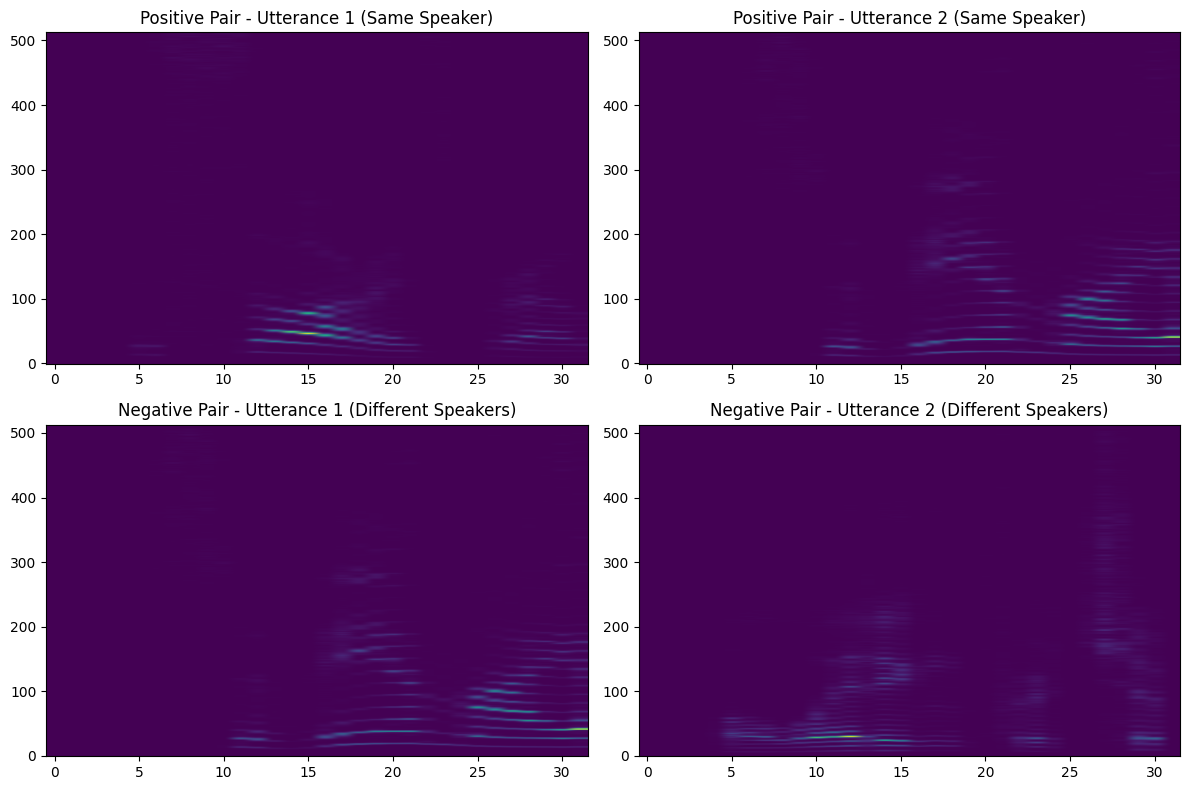


Spectrogram shapes: (513, 32)
Expected: (513, T) where T varies based on signal length


In [73]:
# Visualize a sample spectrogram pair
sample_batch = train_minibatches[0]
sample_pairs, sample_labels = sample_batch

# Get first positive and first negative pair
pos_idx = sample_labels.index(1)
neg_idx = sample_labels.index(0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Positive pair
spec1, spec2 = sample_pairs[pos_idx]
axes[0, 0].imshow(np.abs(spec1), aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Positive Pair - Utterance 1 (Same Speaker)')
axes[0, 1].imshow(np.abs(spec2), aspect='auto', origin='lower', cmap='viridis')
axes[0, 1].set_title('Positive Pair - Utterance 2 (Same Speaker)')

# Negative pair
spec1, spec2 = sample_pairs[neg_idx]
axes[1, 0].imshow(np.abs(spec1), aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_title('Negative Pair - Utterance 1 (Different Speakers)')
axes[1, 1].imshow(np.abs(spec2), aspect='auto', origin='lower', cmap='viridis')
axes[1, 1].set_title('Negative Pair - Utterance 2 (Different Speakers)')

plt.tight_layout()
plt.show()

print(f"\nSpectrogram shapes: {np.abs(spec1).shape}")
print(f"Expected: (513, T) where T varies based on signal length")

The data still needs some preprocessing to be used as input to the network, so we pad the data so its all the same length, and then turn them into tensors for use in PyTorch.

In [74]:
def pad_spectrogram(spec_list):
    max_time = max(spec.shape[1] for spec in spec_list)
    padded_specs = []
    for spec in spec_list:
        if spec.shape[1] < max_time:
          padding = np.zeros((spec.shape[0], max_time - spec.shape[1]))
          padded_spec = np.concatenate([spec, padding], axis=1)
        else:
          padded_spec = spec
        padded_specs.append(padded_spec)
    return torch.tensor(np.stack(padded_specs), dtype=torch.float32)
def preprocess_minibatch(minibatches):
    processd_batches = []
    for batch_idx, (pairs, labels) in enumerate(minibatches):
        spec1_list = [pair[0] for pair in pairs]
        spec2_list = [pair[1] for pair in pairs]
        
        # pad and convert to tensors
        spec1_tensor = pad_spectrogram(spec1_list).to(device)
        spec2_tensor = pad_spectrogram(spec2_list).to(device)
        labels_tensor = torch.tensor(labels, dtype=torch.float32).to(device)
        processd_batches.append((spec1_tensor, spec2_tensor, labels_tensor))
        if (batch_idx + 1) % 10 == 0:
            print(f"Preprocessed {batch_idx + 1}/{len(minibatches)} minibatches...")
    return processd_batches

print("Preprocessing training minibatches...")
train_batches = preprocess_minibatch(train_minibatches)

print("\nPreprocessing test minibatches...")
test_batches = preprocess_minibatch(test_minibatches)

print(f"\nProcessed data summary:")
print(f"Training batches: {len(train_batches)}")
print(f"Test batches: {len(test_batches)}")
print(f"\nSample batch shapes:")
spec1, spec2, labels = train_batches[0]
print(f"  spec1: {spec1.shape}")
print(f"  spec2: {spec2.shape}")
print(f"  labels: {labels.shape}")

Preprocessing training minibatches...
Preprocessed 10/50 minibatches...
Preprocessed 20/50 minibatches...
Preprocessed 30/50 minibatches...
Preprocessed 40/50 minibatches...
Preprocessed 50/50 minibatches...

Preprocessing test minibatches...
Preprocessed 10/20 minibatches...
Preprocessed 20/20 minibatches...

Processed data summary:
Training batches: 50
Test batches: 20

Sample batch shapes:
  spec1: torch.Size([90, 513, 32])
  spec2: torch.Size([90, 513, 32])
  labels: torch.Size([90])


To create the siamese network I create a base embedding network that outputs a 128-dim embedding for each input.

The embedding network has 2 GRU layers followed by a linear layer to get the final embedding.

Then I create the siamese network that uses two copies of the embedding network to process pairs of inputs and compute the cosine similarity between the two embeddings.

In [75]:
class SpectrogramEncoder(torch.nn.Module):
    def __init__(self, input_size=513, hidden_size=256, embedding_size=128, num_layers=2):
        super(SpectrogramEncoder, self).__init__()
        self.gru = torch.nn.GRU(
          input_size, hidden_size, num_layers, batch_first=True,
          dropout=0.3 if num_layers > 1 else 0, bidirectional=True
        )
        self.fc = torch.nn.Sequential(
          torch.nn.Linear(hidden_size * 2, embedding_size),
          torch.nn.ReLU(),
          torch.nn.Dropout(0.3),
          torch.nn.Linear(embedding_size, embedding_size)
        )
        self.embedding_dim = embedding_size
    def forward(self, x):
        x = x.transpose(1, 2)  # (batch, time, 513)
        output, h_n = self.gru(x)
        pooled = torch.mean(output, dim=1)  # (batch, hidden_size*2)
        embedding=self.fc(pooled) # (batch, embedding_size)
        embedding = torch.nn.functional.normalize(embedding, p=2, dim=1)
        return embedding

class SiameseNetwork(torch.nn.Module):
    def __init__(self, input_dim=513, hidden_size=256, embedding_size=128, num_layers=2):
        super(SiameseNetwork, self).__init__()
        self.encoder = SpectrogramEncoder(input_dim, hidden_size, embedding_size, num_layers)
    def forward(self, spec1, spec2):
        emb1 = self.encoder(spec1)
        emb2 = self.encoder(spec2)
        similarity = torch.sum(emb1 * emb2, dim=1)  # Cosine similarity
        prob = torch.sigmoid(similarity)
        return prob

Methods for training and evaluating the siamese network.

In [87]:
def train_siamese(model, batches, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (spec1, spec2, labels) in enumerate(batches):
        # forward
        predictions = model(spec1, spec2)
        loss = criterion(predictions, labels)
        
        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # accuracy calc
        predicted_labels = (predictions >= 0.5).float()
        correct += (predicted_labels == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()
        
    accuracy = correct / total
    avg_loss = total_loss / len(batches)
    return avg_loss, accuracy
  
def evaluate_siamese(model, batches, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for spec1, spec2, labels in batches:
            predictions = model(spec1, spec2)
            loss = criterion(predictions, labels)
            
            predicted_labels = (predictions >= 0.5).float()
            correct += (predicted_labels == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()
            
    avg_loss = total_loss / len(batches)
    accuracy = correct / total
    
    return avg_loss, accuracy

In [90]:
# Initialize model
print("Initializing Siamese Network...")
print("=" * 80)

siamese_model = SiameseNetwork(
    input_dim=513,
    hidden_size=256,
    embedding_size=128,
    num_layers=2
).to(device)

# Count parameters
total_params = sum(p.numel() for p in siamese_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
print("=" * 80)

# Loss and optimizer
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(siamese_model.parameters(), lr=1e-3)

# Training parameters
num_epochs = 50
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print(f"\nTraining for {num_epochs} epochs...")
print("=" * 80)

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_siamese(
        siamese_model, train_batches, optimizer, criterion
    )
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Evaluate
    test_loss, test_acc = evaluate_siamese(
        siamese_model, test_batches, criterion
    )
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | Val Loss: {test_loss:.4f}, Val Acc: {test_acc*100:.2f}%")
    

print("\n" + "=" * 80)
print(f"TRAINING COMPLETE")
print("=" * 80)
print(f"Final Test Accuracy: {test_accuracies[-1]*100:.2f}%")
print("=" * 80)

Initializing Siamese Network...
Total trainable parameters: 2,449,152

Training for 50 epochs...
Epoch [10/50] - Train Loss: 0.5586, Train Acc: 76.44% | Val Loss: 0.5723, Val Acc: 75.67%
Epoch [20/50] - Train Loss: 0.5324, Train Acc: 81.04% | Val Loss: 0.6030, Val Acc: 74.00%
Epoch [30/50] - Train Loss: 0.5159, Train Acc: 83.29% | Val Loss: 0.5780, Val Acc: 75.22%
Epoch [40/50] - Train Loss: 0.5211, Train Acc: 81.84% | Val Loss: 0.5824, Val Acc: 74.17%
Epoch [50/50] - Train Loss: 0.5066, Train Acc: 84.67% | Val Loss: 0.5895, Val Acc: 74.50%

TRAINING COMPLETE
Final Test Accuracy: 74.50%


I trained the network for 50 epochs using the adam optimizer and BCE loss.

I get after 50 epochs a test accuracy of around 75% and a training accuracy around 85%. This is a bit better than the accuracy reported by the assignment.

# Problem 5: Speech Denoising Using RNN

Method to load in the spectrograms from the data files and compute the ibm.

In [ ]:
def load_spectrograms(file_type, prefix='tr', num_files=1200, n_fft=1024, hop_length=512):
    spectrograms = []
    for i in range(num_files):
        filename = f"timit-homework/{prefix}/{file_type}{i:04d}.wav"
        audio, sr = librosa.load(filename, sr=None)
        
        stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length, window='hann')
        magnitude = np.abs(stft)
        spectrograms.append(magnitude)
    return spectrograms
  
def compute_ibm(S_mag, N_mag):
  return (S_mag > N_mag).astype(np.float32)

Loading the data and creating train/test splits.

In [96]:
X_train_list = load_spectrograms('trx')
S_train_list = load_spectrograms('trs')
N_train_list = load_spectrograms('trn')

ibm_train_list = [compute_ibm(S, N) for S, N in zip(S_train_list, N_train_list)]

X_val_list = load_spectrograms('vx', prefix='v')
S_val_list = load_spectrograms('vs', prefix='v')
N_val_list = load_spectrograms('vn', prefix='v')

ibm_val_list = [compute_ibm(S, N) for S, N in zip(S_val_list, N_val_list)]

print("\n" + "=" * 80)
print("VALIDATION DATA SUMMARY")
print("=" * 80)
print(f"Number of validation examples: {len(X_val_list)}")
print(f"Example shapes: {X_val_list[0].shape}")
print("=" * 80)


VALIDATION DATA SUMMARY
Number of validation examples: 1200
Example shapes: (513, 65)


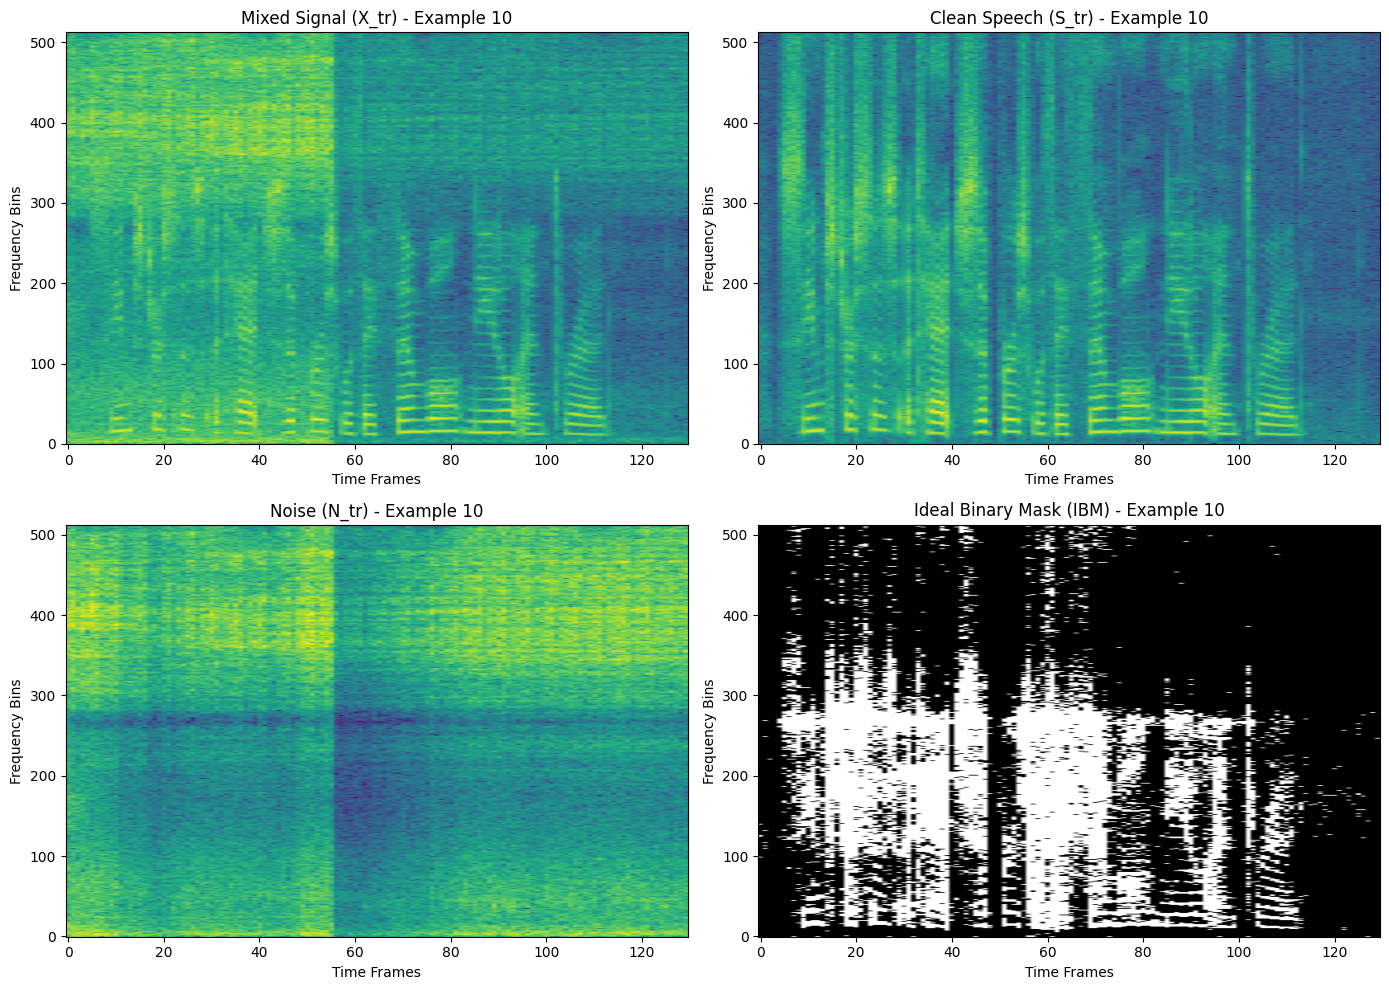

In [99]:
def visualize_denoising_example(idx=0):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    # Mixed (noisy) spectrogram
    axes[0, 0].imshow(20 * np.log10(X_train_list[idx] + 1e-6), 
                      aspect='auto', origin='lower', cmap='viridis')
    axes[0, 0].set_title(f'Mixed Signal (X_tr) - Example {idx}')
    axes[0, 0].set_xlabel('Time Frames')
    axes[0, 0].set_ylabel('Frequency Bins')
    # Clean speech spectrogram
    axes[0, 1].imshow(20 * np.log10(S_train_list[idx] + 1e-6), 
                      aspect='auto', origin='lower', cmap='viridis')
    axes[0, 1].set_title(f'Clean Speech (S_tr) - Example {idx}')
    axes[0, 1].set_xlabel('Time Frames')
    axes[0, 1].set_ylabel('Frequency Bins')
    # Noise spectrogram
    axes[1, 0].imshow(20 * np.log10(N_train_list[idx] + 1e-6), 
                      aspect='auto', origin='lower', cmap='viridis')
    axes[1, 0].set_title(f'Noise (N_tr) - Example {idx}')
    axes[1, 0].set_xlabel('Time Frames')
    axes[1, 0].set_ylabel('Frequency Bins')
    # IBM mask
    axes[1, 1].imshow(ibm_train_list[idx], 
                      aspect='auto', origin='lower', cmap='gray')
    axes[1, 1].set_title(f'Ideal Binary Mask (IBM) - Example {idx}')
    axes[1, 1].set_xlabel('Time Frames')
    axes[1, 1].set_ylabel('Frequency Bins')
    plt.tight_layout()
    plt.show()
visualize_denoising_example(10)

In [100]:
def pad_spectrograms(spec_list):
    max_time = max(spec.shape[1] for spec in spec_list)
    padded_specs = []
    for spec in spec_list:
        if spec.shape[1] < max_time:
            padding = np.zeros((spec.shape[0], max_time - spec.shape[1]))
            padded_spec = np.concatenate([spec, padding], axis=1)
        else:
            padded_spec = spec
        padded_specs.append(padded_spec)
    return torch.tensor(np.stack(padded_specs), dtype=torch.float32)

The data again needs to be padded and converted to tensors for processing.

In [104]:
X_train_fixed = pad_spectrograms(X_train_list)
ibm_train_fixed = pad_spectrograms(ibm_train_list)

X_val_fixed = pad_spectrograms(X_val_list)
ibm_val_fixed = pad_spectrograms(ibm_val_list)

print("\n" + "=" * 80)
print("PROCESSED DATA SHAPES")
print("=" * 80)
print(f"X_train_fixed: {X_train_fixed.shape}")
print(f"IBM_train_fixed: {ibm_train_fixed.shape}")
print(f"X_val_fixed: {X_val_fixed.shape}")
print(f"IBM_val_fixed: {ibm_val_fixed.shape}")
print("=" * 80)


PROCESSED DATA SHAPES
X_train_fixed: torch.Size([1200, 513, 178])
IBM_train_fixed: torch.Size([1200, 513, 178])
X_val_fixed: torch.Size([1200, 513, 178])
IBM_val_fixed: torch.Size([1200, 513, 178])


In this problem I use the dataloader to help train the network since we have a lot more data.

In [105]:
train_dataset_simple = torch.utils.data.TensorDataset(X_train_fixed, ibm_train_fixed)
val_dataset_simple = torch.utils.data.TensorDataset(X_val_fixed, ibm_val_fixed)

batch_size = 32

train_loader_simple = torch.utils.data.DataLoader(
  train_dataset_simple, batch_size=batch_size, shuffle=True,
  num_workers=0, pin_memory=True if device.type == 'cuda' else False
)

val_loader_simple = torch.utils.data.DataLoader(
  val_dataset_simple, batch_size=batch_size, shuffle=False,
  num_workers=0, pin_memory=True if device.type == 'cuda' else False
)

print(f"\nDataLoader created:")
print(f"  Batch size: {batch_size}")
print(f"  Training batches: {len(train_loader_simple)}")
print(f"  Validation batches: {len(val_loader_simple)}")


DataLoader created:
  Batch size: 32
  Training batches: 38
  Validation batches: 38


My network for this problem uses 2 GRU layers and 2 linear layers to output the predicted ibm mask.

In [107]:
class DenoisingNN(torch.nn.Module):
    def __init__(self, input_size=513, hidden_size=512, num_layers=2, dropout=0.3):
        super(DenoisingNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.flatten = torch.nn.Flatten()
        self.rnn = torch.nn.GRU(
          input_size=input_size,
          hidden_size=hidden_size,
          num_layers=num_layers,
          batch_first=True,
          dropout=dropout if num_layers > 1 else 0,
          bidirectional=True
        )
        self.fc = torch.nn.Sequential(
          torch.nn.Linear(hidden_size * 2, hidden_size),
          torch.nn.ReLU(),
          torch.nn.Dropout(dropout),
          torch.nn.Linear(hidden_size, input_size),
          torch.nn.Sigmoid() # output mask between 0 and 1
        )
    def forward(self, x):
        x = x.transpose(1, 2)  # (batch, time, freq)
        output, _ = self.rnn(x)
        mask = self.fc(output)  # (batch, time, freq)
        mask = mask.transpose(1, 2)  # (batch, freq, time)
        return mask

Methods for training and evaluating the denoising network. I decide to clip the gradients for the rnn to help with training stability.

In [108]:
def train_denoising_rnn(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, ibm_batch in train_loader:
        X_batch = X_batch.to(device)
        ibm_batch = ibm_batch.to(device)
        
        # forward
        predicted_mask = model(X_batch)
        loss = criterion(predicted_mask, ibm_batch)
        
        # backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    return avg_loss
def evaluate_denoising_rnn(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, ibm_batch in val_loader:
            X_batch = X_batch.to(device)
            ibm_batch = ibm_batch.to(device)
            
            predicted_mask = model(X_batch)
            loss = criterion(predicted_mask, ibm_batch)
            total_loss += loss.item()
    avg_loss = total_loss / len(val_loader)
    return avg_loss
def compute_snr_batch(clean_specs, denoised_specs):
    snr_values = []
    for clean, denoised in zip(clean_specs, denoised_specs):
        noise = clean - denoised
        signal_power = torch.sum(clean ** 2)
        noise_power = torch.sum(noise ** 2)
        if noise_power > 1e-10:
            snr_db = 10 * torch.log10(signal_power / noise_power)
            snr_values.append(snr_db.item())
    return np.mean(snr_values) if snr_values else 0.0

In [109]:
denoising_model = DenoisingNN().to(device)
criterion = torch.nn.BCELoss() # binary cross entroy
optimizer = torch.optim.Adam(denoising_model.parameters(), lr=1e-3)

num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_denoising_rnn(
        denoising_model, train_loader_simple, optimizer, criterion
    )
    val_loss = evaluate_denoising_rnn(
        denoising_model, val_loader_simple, criterion
    )
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch [5/50] - Train Loss: 0.2818 | Val Loss: 0.2654
Epoch [10/50] - Train Loss: 0.2463 | Val Loss: 0.2478
Epoch [15/50] - Train Loss: 0.2275 | Val Loss: 0.2270
Epoch [20/50] - Train Loss: 0.2151 | Val Loss: 0.2191
Epoch [25/50] - Train Loss: 0.2089 | Val Loss: 0.2125
Epoch [30/50] - Train Loss: 0.1987 | Val Loss: 0.2094
Epoch [35/50] - Train Loss: 0.1951 | Val Loss: 0.2101
Epoch [40/50] - Train Loss: 0.1891 | Val Loss: 0.2056
Epoch [45/50] - Train Loss: 0.1864 | Val Loss: 0.2052
Epoch [50/50] - Train Loss: 0.1809 | Val Loss: 0.2036


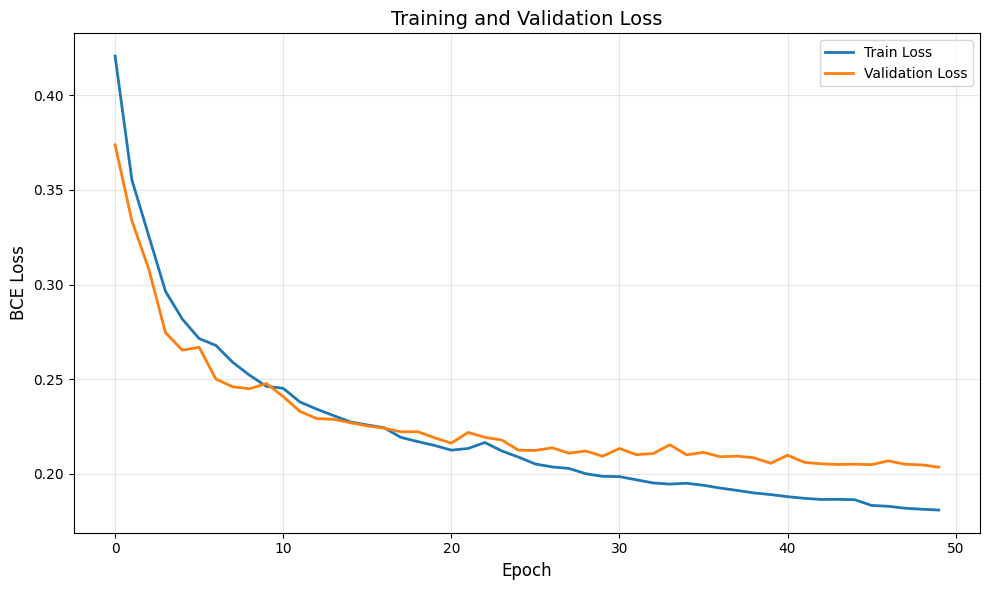

In [112]:
plt.figure(figsize=(10, 6))

plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('BCE Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [117]:
print("\n" + "=" * 80)
print("BASELINE SNR EVALUATION (No Denoising)")
print("=" * 80)

# Calculate SNR of noisy input vs clean speech
baseline_snr_values = []

with torch.no_grad():
    for i in range(0, len(X_val_fixed), batch_size):
        X_batch = X_val_fixed[i:i+batch_size].to(device)  # Noisy input
        S_batch = S_val_fixed[i:i+batch_size].to(device)  # Clean speech
        
        # Compute SNR between clean speech and noisy input
        snr_batch = compute_snr_batch(S_batch, X_batch)
        baseline_snr_values.append(snr_batch)

baseline_avg_snr = np.mean(baseline_snr_values)
print(f"Average Baseline SNR (Noisy Input): {baseline_avg_snr:.2f} dB")
print("=" * 80)


BASELINE SNR EVALUATION (No Denoising)
Average Baseline SNR (Noisy Input): 0.46 dB


In [118]:
print("\n" + "=" * 80)
print("VALIDATION SET SNR EVALUATION")
print("=" * 80)
S_val_fixed = pad_spectrograms(S_val_list)
denoising_model.eval()
all_snr_values = []

with torch.no_grad():
    for i in range(0, len(X_val_fixed), batch_size):
        X_batch = X_val_fixed[i:i+batch_size].to(device)
        S_batch = S_val_fixed[i:i+batch_size].to(device)
        predicted_mask = denoising_model(X_batch)
        denoised_batch = predicted_mask * X_batch
        snr_batch = compute_snr_batch(S_batch, denoised_batch)
        all_snr_values.append(snr_batch)

avg_snr = np.mean(all_snr_values)
print(f"Average Validation SNR: {avg_snr:.2f} dB")
print("=" * 80)


VALIDATION SET SNR EVALUATION
Average Validation SNR: 9.99 dB


In [119]:
for i in range(len(all_snr_values)):
    print(f"Batch {i+1}: SNR = {all_snr_values[i]:.2f} dB")

Batch 1: SNR = 7.22 dB
Batch 2: SNR = 8.19 dB
Batch 3: SNR = 8.33 dB
Batch 4: SNR = 10.04 dB
Batch 5: SNR = 9.91 dB
Batch 6: SNR = 10.59 dB
Batch 7: SNR = 10.18 dB
Batch 8: SNR = 10.66 dB
Batch 9: SNR = 11.57 dB
Batch 10: SNR = 11.02 dB
Batch 11: SNR = 12.04 dB
Batch 12: SNR = 11.40 dB
Batch 13: SNR = 9.79 dB
Batch 14: SNR = 8.37 dB
Batch 15: SNR = 8.41 dB
Batch 16: SNR = 8.60 dB
Batch 17: SNR = 10.52 dB
Batch 18: SNR = 10.50 dB
Batch 19: SNR = 10.19 dB
Batch 20: SNR = 9.14 dB
Batch 21: SNR = 9.47 dB
Batch 22: SNR = 9.88 dB
Batch 23: SNR = 11.12 dB
Batch 24: SNR = 10.23 dB
Batch 25: SNR = 10.90 dB
Batch 26: SNR = 10.45 dB
Batch 27: SNR = 10.55 dB
Batch 28: SNR = 10.94 dB
Batch 29: SNR = 10.40 dB
Batch 30: SNR = 10.68 dB
Batch 31: SNR = 10.30 dB
Batch 32: SNR = 11.71 dB
Batch 33: SNR = 11.46 dB
Batch 34: SNR = 11.46 dB
Batch 35: SNR = 9.02 dB
Batch 36: SNR = 8.45 dB
Batch 37: SNR = 7.53 dB
Batch 38: SNR = 8.52 dB


After having trained the denoising network we can calculate the snr improvements on the validation set.

We see that the original data is very noisy and gains around 9 dB of improvement after denoising.

The average snr ends up at just below 10 dB after denoising which is around what I expected.

Below I give a way to test a specific sample and save the denoised audio to a file to listen to the results. I also visualize the spectrograms for the noisy, clean, and denoised signals, and the snr improvement.

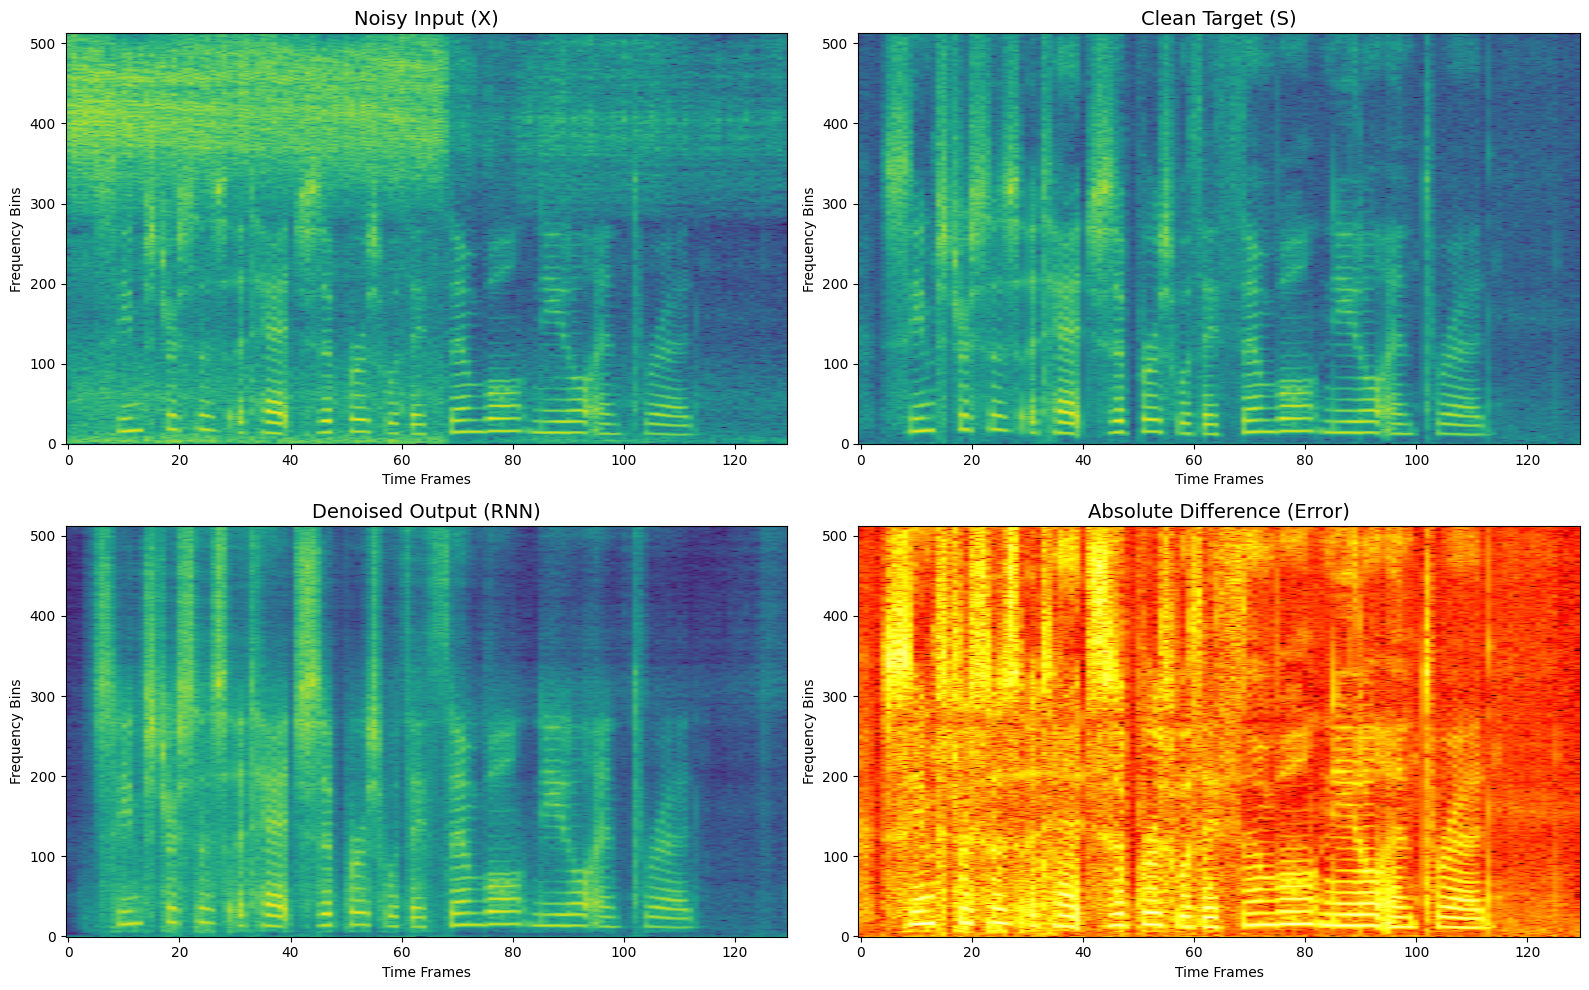


Sample 10 SNR:
  Baseline (Noisy):  0.37 dB
  After Denoising:   10.35 dB
  Improvement:       +9.99 dB

Playback:
--------------------------------------------------------------------------------
Noisy Input:



Denoised Output:


--------------------------------------------------------------------------------


In [123]:
sample_idx = 10

X_sample = X_val_list[sample_idx]  # Noisy spectrogram
S_sample = S_val_list[sample_idx]  # Clean spectrogram

# Get denoised version - need to match the preprocessing
X_sample_tensor = torch.tensor(X_sample, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    predicted_mask = denoising_model(X_sample_tensor)
    denoised_sample = (predicted_mask * X_sample_tensor).squeeze(0).cpu().numpy()

# Visualize spectrograms
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Noisy input
axes[0, 0].imshow(20 * np.log10(X_sample + 1e-6), 
                  aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Noisy Input (X)', fontsize=14)
axes[0, 0].set_xlabel('Time Frames')
axes[0, 0].set_ylabel('Frequency Bins')

# Clean target
axes[0, 1].imshow(20 * np.log10(S_sample + 1e-6), 
                  aspect='auto', origin='lower', cmap='viridis')
axes[0, 1].set_title('Clean Target (S)', fontsize=14)
axes[0, 1].set_xlabel('Time Frames')
axes[0, 1].set_ylabel('Frequency Bins')

# Denoised output
axes[1, 0].imshow(20 * np.log10(denoised_sample + 1e-6), 
                  aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_title('Denoised Output (RNN)', fontsize=14)
axes[1, 0].set_xlabel('Time Frames')
axes[1, 0].set_ylabel('Frequency Bins')

# Difference (error)
difference = np.abs(S_sample - denoised_sample)
axes[1, 1].imshow(20 * np.log10(difference + 1e-6), 
                  aspect='auto', origin='lower', cmap='hot')
axes[1, 1].set_title('Absolute Difference (Error)', fontsize=14)
axes[1, 1].set_xlabel('Time Frames')
axes[1, 1].set_ylabel('Frequency Bins')

plt.tight_layout()
plt.show()

# Calculate SNR for this sample
def snr(clean, denoised):
    noise = clean - denoised
    snr_val = 10 * torch.log10(torch.sum(clean ** 2) / torch.sum(noise ** 2))
    return snr_val

sample_base_snr = snr(torch.tensor(S_sample), torch.tensor(X_sample))
sample_denoised_snr = snr(torch.tensor(S_sample), torch.tensor(denoised_sample))

print(f"\nSample {sample_idx} SNR:")
print(f"  Baseline (Noisy):  {sample_base_snr:.2f} dB")
print(f"  After Denoising:   {sample_denoised_snr:.2f} dB")
print(f"  Improvement:       {sample_denoised_snr - sample_base_snr:+.2f} dB")
print("=" * 80)

noisy_audio, sr = librosa.load(f'timit-homework/v/vx{sample_idx:04d}.wav', sr=None)

# We need the phase from the noisy signal
noisy_stft = librosa.stft(noisy_audio, n_fft=1024, hop_length=512, window='hann')
noisy_phase = np.angle(noisy_stft)

# Combine denoised magnitude with noisy phase
denoised_stft = denoised_sample * np.exp(1j * noisy_phase)
denoised_audio = librosa.istft(denoised_stft, hop_length=512, window='hann')

sf.write('sample_noisy.wav', noisy_audio, sr)
sf.write('sample_denoised.wav', denoised_audio, sr)

print("\nPlayback:")
print("-" * 80)
print("Noisy Input:")
display(Audio('sample_noisy.wav'))
print("\nDenoised Output:")
display(Audio('sample_denoised.wav'))
print("-" * 80)

Here I denoise the test data and save the denoised audio files to disk for listening. This is the data submitted with this homework for grading.

In [126]:
import os
output_dir = 'denoised_outputs'
os.makedirs(output_dir, exist_ok=True)

test_dir = 'timit-homework/te'
test_files = sorted([f for f in os.listdir(test_dir) if f.startswith('tex') and f.endswith('.wav')])

print(f"Found {len(test_files)} test files to process")
print("=" * 80)

denoising_model.eval()

with torch.no_grad():
    for i, test_file in enumerate(test_files):
        # Load noisy test audio
        noisy_audio, sr = librosa.load(os.path.join(test_dir, test_file), sr=None)
        
        # Compute STFT
        noisy_stft = librosa.stft(noisy_audio, n_fft=1024, hop_length=512, window='hann')
        noisy_magnitude = np.abs(noisy_stft)
        noisy_phase = np.angle(noisy_stft)
        
        # Prepare input tensor
        X_test = torch.tensor(noisy_magnitude, dtype=torch.float32).unsqueeze(0).to(device)
        
        # Predict mask
        predicted_mask = denoising_model(X_test)
        
        # Apply mask to get denoised magnitude
        denoised_magnitude = (predicted_mask * X_test).squeeze(0).cpu().numpy()
        
        # Reconstruct audio using denoised magnitude and original phase
        denoised_stft = denoised_magnitude * np.exp(1j * noisy_phase)
        denoised_audio = librosa.istft(denoised_stft, hop_length=512, window='hann')
        
        # Save denoised audio
        output_filename = test_file.replace('tex', 'tes')  # Change prefix from tex to tes
        output_path = os.path.join(output_dir, output_filename)
        sf.write(output_path, denoised_audio, sr)
        
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(test_files)} files...")

print("=" * 80)
print(f"PROCESSING COMPLETE")
print(f"Denoised files saved to: {output_dir}/")
print("=" * 80)

Found 400 test files to process
Processed 50/400 files...
Processed 100/400 files...
Processed 150/400 files...
Processed 200/400 files...
Processed 250/400 files...
Processed 300/400 files...
Processed 350/400 files...
Processed 400/400 files...
PROCESSING COMPLETE
Denoised files saved to: denoised_outputs/
